c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.1352 - loss: 2.7012 - val_accuracy: 0.1333 - val_loss: 2.6955
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2101 - loss: 2.6584 - val_accuracy: 0.2333 - val_loss: 2.6797
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3303 - loss: 2.6036 - val_accuracy: 0.2500 - val_loss: 2.6517
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3557 - loss: 2.5078 - val_accuracy: 0.2167 - val_loss: 2.6179
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3729 - loss: 2.3900 - val_accuracy: 0.3000 - val_loss: 2.5493
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3447 - loss: 2.2366 - val_accuracy: 0.3167 - val_loss: 2.4473
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4973 - loss: 1.9747 - val_accuracy: 0.3167 - val_loss: 2.3310
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4826 - loss: 1.7786 - val_accuracy: 0.3500 - val_loss: 2.1590


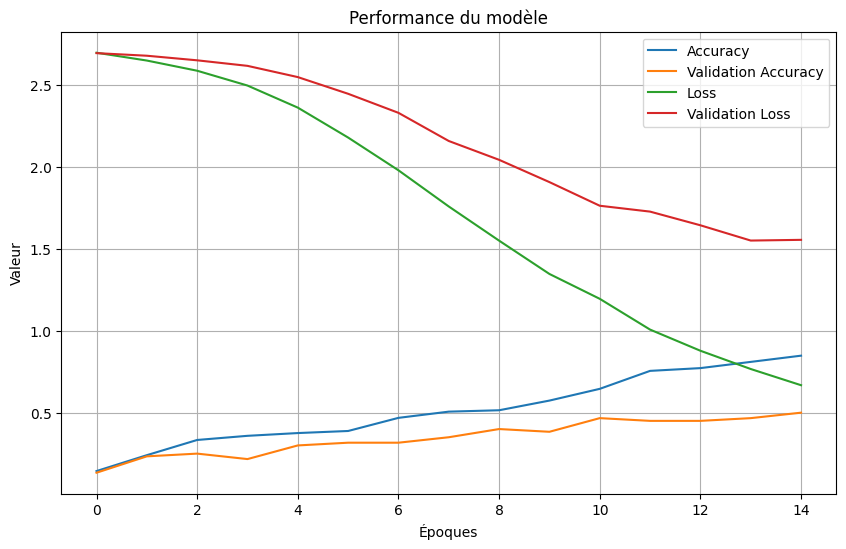

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import re
import random

# --- Fonctions de Data Augmentation Supplémentaires ---

def rename_variables(code):
    var_names = re.findall(r'\b[a-zA-Z_][a-zA-Z_0-9]*\b', code)
    keywords = {'int', 'float', 'char', 'return', 'while', 'if', 'else', 'for', 'printf', 'main'}
    var_names = [v for v in set(var_names) if v not in keywords]
    rename_map = {var: f"var_{i}" for i, var in enumerate(var_names)}
    for orig, new in rename_map.items():
        code = re.sub(rf'\b{orig}\b', new, code)
    return code

def add_random_comment(code):
    comments = [
        "// temporary variable",
        "// fix later",
        "// check bounds",
        "// debug this",
        "// init stuff",
        "// TODO: handle edge case"
    ]
    lines = code.split('\n')
    if lines:
        idx = random.randint(0, len(lines) - 1)
        lines.insert(idx, random.choice(comments))
    return "\n".join(lines)

def permute_lines(code):
    lines = code.split('\n')
    if len(lines) > 3:
        mid_lines = lines[1:-1]
        random.shuffle(mid_lines)
        return "\n".join([lines[0]] + mid_lines + [lines[-1]])
    return code

def misspell_keywords(code):
    typo_map = {
        'return': 'retrn',
        'int': 'iint',
        'char': 'charr',
        'float': 'flaot',
        'while': 'whle',
        'for': 'foor',
        'printf': 'printff',
        'else': 'els',
        'break': 'brek'
    }
    for key, typo in typo_map.items():
        if random.random() < 0.3:
            code = code.replace(key, typo)
    return code

def random_whitespace(code):
    code = re.sub(r' {2,}', ' ', code)
    code = re.sub(r'\t', '    ', code)
    if random.random() < 0.5:
        code = re.sub(r'\s+', ' ', code)
    return code

def alter_comparisons(code):
    # Inverser les comparaisons pour plus de bruit
    if "==" in code and random.random() < 0.3:
        code = code.replace("==", "!=")
    return code

def rename_functions(code):
    matches = re.findall(r'\b[a-zA-Z_][a-zA-Z_0-9]*\s*\(', code)
    for m in matches:
        fn_name = m.split('(')[0].strip()
        if fn_name not in ['if', 'for', 'while', 'return', 'switch', 'main']:
            new_name = f"func_{random.randint(100, 999)}"
            code = re.sub(rf'\b{fn_name}\b', new_name, code)
    return code

def alter_data_types(code):
    # Remplacer 'int' par 'float' et inversement
    if random.random() < 0.4:
        code = code.replace('int', 'float') if random.random() < 0.5 else code.replace('float', 'int')
    return code

def change_loop_type(code):
    # Remplacer les boucles for par des while et vice versa
    if "for" in code and random.random() < 0.3:
        code = code.replace('for', 'while')
    elif "while" in code and random.random() < 0.3:
        code = code.replace('while', 'for')
    return code

# --- Fonction Principale d'Augmentation ---
def augment_dataset(df, n_variants=10):
    augmented_data = []
    for _, row in df.iterrows():
        original_code = row['code']
        error_type = row['erreurs']
        augmented_data.append((original_code, error_type))
        for _ in range(n_variants):
            variant = original_code
            if random.random() < 0.9:
                variant = rename_variables(variant)
            if random.random() < 0.7:
                variant = rename_functions(variant)
            if random.random() < 0.6:
                variant = add_random_comment(variant)
            if random.random() < 0.5:
                variant = permute_lines(variant)
            if random.random() < 0.6:
                variant = misspell_keywords(variant)
            if random.random() < 0.5:
                variant = random_whitespace(variant)
            if random.random() < 0.4:
                variant = alter_comparisons(variant)
            if random.random() < 0.3:
                variant = alter_data_types(variant)
            if random.random() < 0.2:
                variant = change_loop_type(variant)
            augmented_data.append((variant, error_type))
    return pd.DataFrame(augmented_data, columns=["code", "erreurs"])

# --- Chargement des données ---

# Lecture du CSV
df = pd.read_csv("code_errors_dataset.csv")

# Augmentation du dataset
df_augmented = augment_dataset(df)

# --- Préparation des données ---
X = df_augmented['code']
y = df_augmented['erreurs']

# Encodage des labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# TF-IDF vectorisation
vectorizer = TfidfVectorizer(max_features=8000)
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

# --- Modèle ---
model = Sequential()
model.add(Dense(512, input_dim=X_train_vect.shape[1], activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(len(label_encoder.classes_), activation='softmax'))

# Compilation
model.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entraînement
history = model.fit(X_train_vect.toarray(), y_train, epochs=15, batch_size=32, validation_data=(X_test_vect.toarray(), y_test))

# --- Visualisation ---
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Performance du modèle")
plt.xlabel("Époques")
plt.ylabel("Valeur")
plt.legend()
plt.grid(True)
plt.show()


In [11]:
import torch


In [6]:
import numpy as np
import tkinter as tk
from tkinter import filedialog

# Fonction de prédiction des erreurs à partir du code source
def predict_errors_from_code(code, model, vectorizer, label_encoder):
    code_vect = vectorizer.transform([code]).toarray()
    predicted_label = model.predict(code_vect)
    predicted_class = np.argmax(predicted_label, axis=1)[0]
    error_type = label_encoder.inverse_transform([predicted_class])[0]
    return error_type

# Fonction pour analyser un fichier .c ligne par ligne
def analyze_code_for_errors(file_path, model, vectorizer, label_encoder):
    with open(file_path, 'r') as file:
        code_lines = file.readlines()

    errors = []

    for line_number, line in enumerate(code_lines, start=1):
        error_type = predict_errors_from_code(line.strip(), model, vectorizer, label_encoder)
        if error_type != 'aucune erreur':
            errors.append((line_number, error_type, line.strip()))

    return errors

# Fenêtre de sélection de fichier (.c)
root = tk.Tk()
root.withdraw()  # Cacher la fenêtre principale
file_path = filedialog.askopenfilename(filetypes=[("C files", "*.c")])

if file_path:
    errors = analyze_code_for_errors(file_path, model, vectorizer, label_encoder)

    if errors:
        print(f"Erreurs détectées dans le fichier {file_path} :\n")
        for line_number, error_type, line in errors:
            print(f"Ligne {line_number}: {error_type} - {line}")
    else:
        print(f"Aucune erreur détectée dans le fichier {file_path}.")
else:
    print("Aucun fichier sélectionné.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Erreurs détectées dans le fichier C:/Users/DELL/Desktop/ok.c :

Ligne 1: redeclaration_variable - int main() {
Ligne 2: redeclaration_variable - int a;
Ligne 3: type_incompatible - float x = 'Hello'
Ligne 4: out_of_bounds - int arr[3];
Ligne 5: out_of_bounds - arr[5] = 10;
Ligne 6: affectation_dans_condition - if (a = 5) {
Ligne 7: boucle_infinie - while(1) {
Ligne 8: boucle_infinie - }
Ligne 9: boucle_infinie - }
Ligne 10: out_of_bounds - int a = 20;
Lig

In [25]:
import joblib
model.save("model.h5")
joblib.dump(vectorizer, "vectorizer.joblib")
joblib.dump(label_encoder, "label_encoder.joblib")


['label_encoder.joblib']

In [26]:
pip install flask joblib tensorflow scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
